In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi oku
df = pd.read_csv('../data/twcs.csv')

print(f"Satır: {df.shape[0]}, Sütun: {df.shape[1]}")
df.head()

Satır: 2811774, Sütun: 7


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [2]:
print(f"Boş değerler:\n{df.isnull().sum()}")
print(f"\nKaç farklı şirket var: {df[df['inbound']==False]['author_id'].nunique()}")
print(f"\nŞirketler:\n{df[df['inbound']==False]['author_id'].value_counts().head(10)}")

Boş değerler:
tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64

Kaç farklı şirket var: 108

Şirketler:
author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
Name: count, dtype: int64


In [3]:
# Sadece müşteri tweetleri
musteri = df[df['inbound'] == True].copy()

print(f"Toplam müşteri tweeti: {len(musteri)}")

# Şirket başına müşteri şikayeti
print(f"\nŞirkete göre müşteri tweeti (ilk 10):")
print(df[df['inbound']==True]['author_id'].value_counts().head(10))

Toplam müşteri tweeti: 1537843

Şirkete göre müşteri tweeti (ilk 10):
author_id
115911    1286
120576    1010
115913     563
116230     454
169172     448
117627     406
115888     332
116136     295
116421     276
115722     252
Name: count, dtype: int64


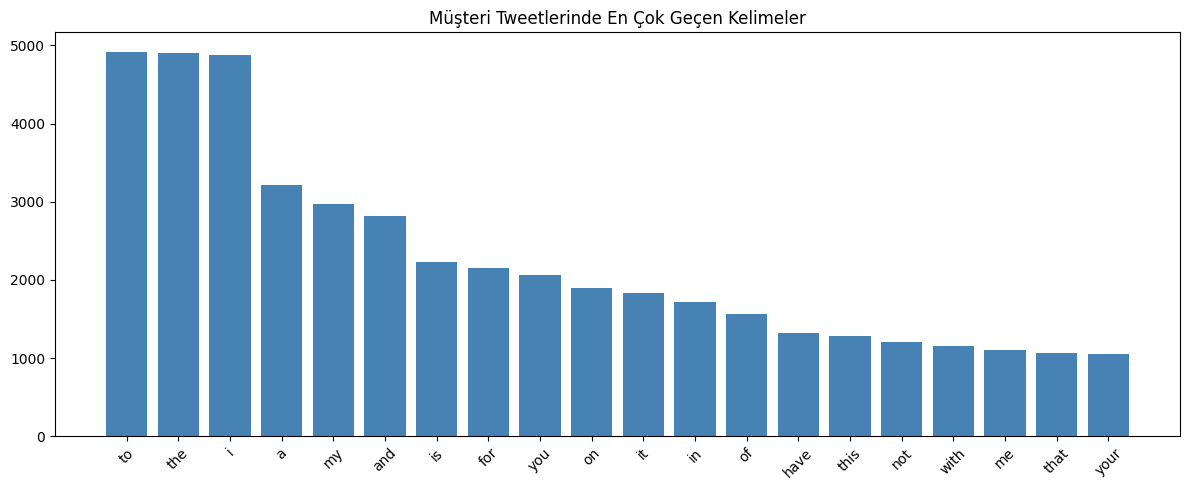

In [4]:
# Müşteri tweetlerinde en çok geçen kelimeler
from collections import Counter
import re

# @ mentions ve linkleri temizle
def temizle(text):
    text = re.sub(r'@\w+', '', str(text))
    text = re.sub(r'http\S+', '', text)
    text = text.lower().strip()
    return text

musteri['clean_text'] = musteri['text'].apply(temizle)

# En çok geçen kelimeler
tum_kelimeler = ' '.join(musteri['clean_text'].sample(10000)).split()
kelime_sayisi = Counter(tum_kelimeler).most_common(20)

kelimeler = [k[0] for k in kelime_sayisi]
sayilar = [k[1] for k in kelime_sayisi]

plt.figure(figsize=(12, 5))
plt.bar(kelimeler, sayilar, color='steelblue')
plt.title('Müşteri Tweetlerinde En Çok Geçen Kelimeler')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\beril.oztan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


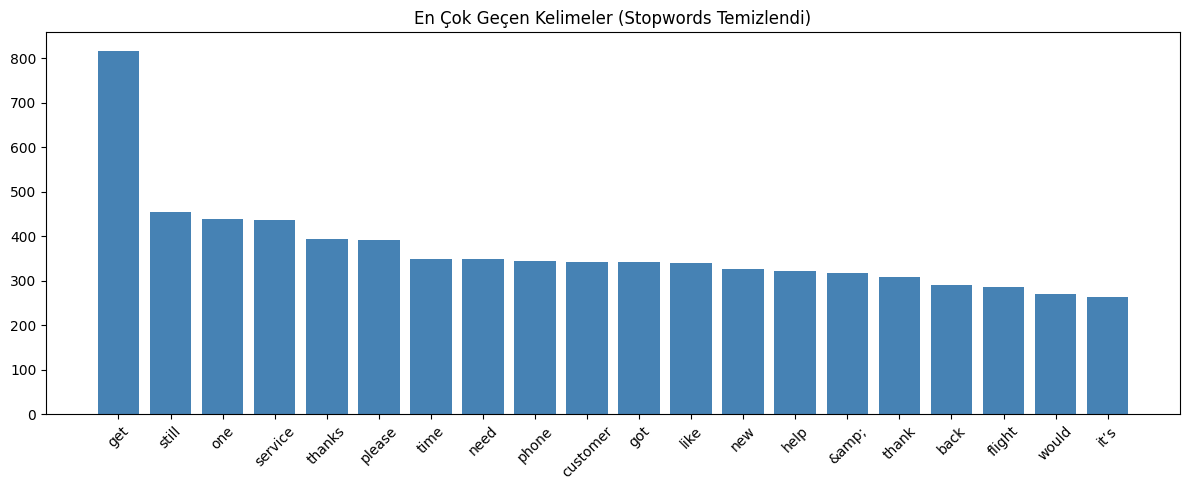

In [6]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def temizle_v2(text):
    text = re.sub(r'@\w+', '', str(text))
    text = re.sub(r'http\S+', '', text)
    text = text.lower().strip()
    kelimeler = [k for k in text.split() if k not in stop_words and len(k) > 2]
    return ' '.join(kelimeler)

musteri['clean_text'] = musteri['text'].apply(temizle_v2)

# Tekrar çiz
tum_kelimeler = ' '.join(musteri['clean_text'].sample(10000)).split()
kelime_sayisi = Counter(tum_kelimeler).most_common(20)

kelimeler = [k[0] for k in kelime_sayisi]
sayilar = [k[1] for k in kelime_sayisi]

plt.figure(figsize=(12, 5))
plt.bar(kelimeler, sayilar, color='steelblue')
plt.title('En Çok Geçen Kelimeler (Stopwords Temizlendi)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

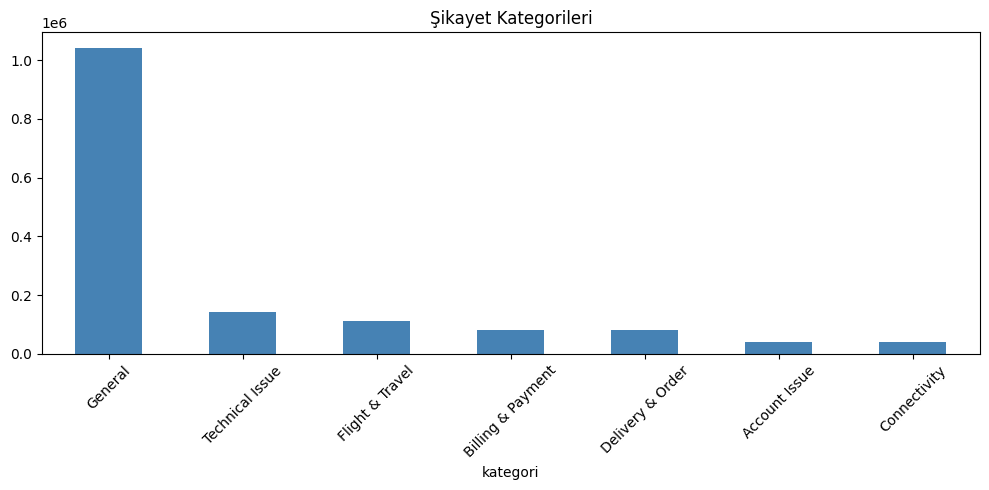

In [7]:
# Anahtar kelimelerle şikayet kategorisi belirle
def kategori_belirle(text):
    text = str(text).lower()
    if any(k in text for k in ['flight', 'delay', 'cancel', 'airport', 'baggage']):
        return 'Flight & Travel'
    elif any(k in text for k in ['bill', 'charge', 'refund', 'payment', 'money']):
        return 'Billing & Payment'
    elif any(k in text for k in ['phone', 'device', 'broken', 'fix', 'repair']):
        return 'Technical Issue'
    elif any(k in text for k in ['slow', 'internet', 'connection', 'network', 'signal']):
        return 'Connectivity'
    elif any(k in text for k in ['order', 'delivery', 'shipping', 'package', 'arrived']):
        return 'Delivery & Order'
    elif any(k in text for k in ['account', 'login', 'password', 'access']):
        return 'Account Issue'
    else:
        return 'General'

musteri['kategori'] = musteri['clean_text'].apply(kategori_belirle)

# Dağılım
musteri['kategori'].value_counts().plot(kind='bar', color='steelblue', figsize=(10,5))
plt.title('Şikayet Kategorileri')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
musteri.to_csv('../data/musteri_tweetleri.csv', index=False)
print("Kaydedildi!")